In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [3]:
ctype = np.float64

### `init_grid` 
input: `shape`: (shape of a grid) ; `threshold`: density of the living cells 
output: `grid` 2darray of boolean 
initialize a random grid (2darray) of double float of dimension shape (the threshold help to define density)

In [4]:
def init_grid(shape, threshold=0.50):
    """
    initialize a random  grid of double float 
    of dimension shape (the threshold help to define density)
    """
    x = np.zeros(shape,dtype=ctype)
    r = np.random.random(shape)
    x[:,:] = (r> 1.0 - threshold)
    return x

In [24]:
def get_nbneigh(grid, coord):
    irange, jrange = grid.shape
    i, j = coord
    biinf = max(0, i - 1)
    bisup = min(irange - 1, i + 1)
    bjinf = max(0,j - 1)
    bjsup = min(jrange - 1,j + 1)
    nb_neigh = 0
    # loop over neighs to count living cells
    for ii in range(biinf, bisup + 1):
        for jj in range(bjinf, bjsup + 1):
            if grid[ii, jj]:
                nb_neigh = nb_neigh + 1
    # in my count I count current cell itself substract the value
    nb_neigh = nb_neigh-grid[i, j]
    return nb_neigh

### `life_step(grid)` : 
- input: `grid` a 2darray of cells (boolean); 
- output: `res_grid`  2darray ; the state of each cell of `grid` resulting from the application of the rules

In [27]:
def life_step(grid):
    irange, jrange = grid.shape
    res_grid = np.zeros(grid.shape,dtype=ctype)
    for j in range(jrange):
        for i in range(irange):
            # by default cell_state is dead
            cell_state = False
            # loop over neighs to count living cells
            nb_neigh = get_nbneigh(grid,(i,j))
            # if 2 neighbors cell state isn't modified
            if nb_neigh == 2:
                cell_state = grid[i, j]
            # if 3 neighbors cell state is alive
            elif nb_neigh == 3:
                cell_state = 1
            # in other case cell state is dead (default state)
            res_grid[i, j] = cell_state
    return res_grid

### `conway(grid,n)`
From an initial grid, run n iterations of evolution and display the intermediate statistics (number of alive cells)

In [34]:
def conway(grid, n):
    """
    From an initial grid, run n iterations of evolution and display 
    the intermediate statistics (number of alive cells)
    """
    for i in range(n):
        alive = np.sum(grid)
        print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')
        grid = life_step(grid)
    return grid

### Exemple on a little grid

In [41]:
grid = init_grid((10,10), 0.5)

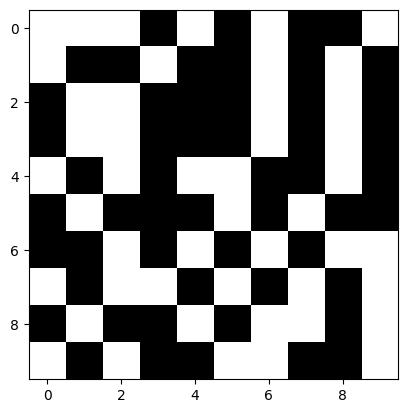

In [43]:
plt.imshow(grid,cmap=plt.cm.binary)

In [44]:
grid = life_step(grid)

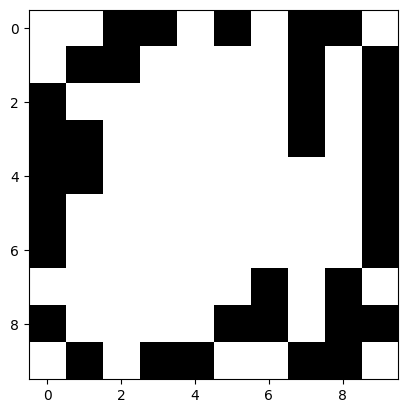

In [45]:
plt.imshow(grid,cmap=plt.cm.binary)

In [46]:
conway(grid,5)

alive cells: 35: 35.00%
alive cells: 36: 36.00%
alive cells: 22: 22.00%
alive cells: 11: 11.00%
alive cells: 8: 8.00%


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1.]])

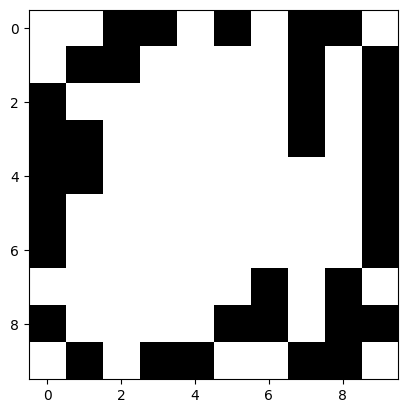

In [47]:
plt.imshow(grid,cmap=plt.cm.binary)

## Question 1.a 
Utilisez le notebook avec différentes tailles progressivement croissantes ((10,10) (100,100), (1000, 1000), (2000, 2000), …) et estimer les temps d’exécution de `conway` avec la commande magique `%time`

In [48]:
grid = init_grid((10,10), 0.5)
%time conway(grid,10)

alive cells: 47: 47.00%
alive cells: 37: 37.00%
alive cells: 26: 26.00%
alive cells: 31: 31.00%
alive cells: 27: 27.00%
alive cells: 24: 24.00%
alive cells: 26: 26.00%
alive cells: 24: 24.00%
alive cells: 24: 24.00%
alive cells: 21: 21.00%
CPU times: user 1.85 ms, sys: 0 ns, total: 1.85 ms
Wall time: 1.85 ms


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 1., 1., 1., 0., 0.],
       [0., 0., 1., 1., 0., 0., 0., 1., 1., 1.],
       [0., 0., 1., 0., 0., 1., 1., 1., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 0.]])

In [49]:
grid = init_grid((100,100), 0.5)
%time conway(grid,100)

alive cells: 4962: 49.62%
alive cells: 2916: 29.16%
alive cells: 2696: 26.96%
alive cells: 2498: 24.98%
alive cells: 2365: 23.65%
alive cells: 2258: 22.58%
alive cells: 2267: 22.67%
alive cells: 2171: 21.71%
alive cells: 2136: 21.36%
alive cells: 2147: 21.47%
alive cells: 2070: 20.70%
alive cells: 2038: 20.38%
alive cells: 1987: 19.87%
alive cells: 1950: 19.50%
alive cells: 1936: 19.36%
alive cells: 1914: 19.14%
alive cells: 1876: 18.76%
alive cells: 1761: 17.61%
alive cells: 1729: 17.29%
alive cells: 1733: 17.33%
alive cells: 1711: 17.11%
alive cells: 1613: 16.13%
alive cells: 1530: 15.30%
alive cells: 1506: 15.06%
alive cells: 1523: 15.23%
alive cells: 1522: 15.22%
alive cells: 1488: 14.88%
alive cells: 1493: 14.93%
alive cells: 1470: 14.70%
alive cells: 1468: 14.68%
alive cells: 1480: 14.80%
alive cells: 1421: 14.21%
alive cells: 1422: 14.22%
alive cells: 1308: 13.08%
alive cells: 1362: 13.62%
alive cells: 1307: 13.07%
alive cells: 1312: 13.12%
alive cells: 1293: 12.93%
alive cells:

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(100, 100))

In [51]:
grid = init_grid((1000,1000), 0.5)
%time conway(grid,50)

alive cells: 499976: 50.00%
alive cells: 274197: 27.42%
alive cells: 252757: 25.28%
alive cells: 250133: 25.01%
alive cells: 237680: 23.77%
alive cells: 231231: 23.12%
alive cells: 222541: 22.25%
alive cells: 216338: 21.63%
alive cells: 209690: 20.97%
alive cells: 203748: 20.37%
alive cells: 198737: 19.87%
alive cells: 192743: 19.27%
alive cells: 189862: 18.99%
alive cells: 185693: 18.57%
alive cells: 181108: 18.11%
alive cells: 177408: 17.74%
alive cells: 173167: 17.32%
alive cells: 169311: 16.93%
alive cells: 165907: 16.59%
alive cells: 163429: 16.34%
alive cells: 160688: 16.07%
alive cells: 158641: 15.86%
alive cells: 156266: 15.63%
alive cells: 154821: 15.48%
alive cells: 152276: 15.23%
alive cells: 149880: 14.99%
alive cells: 147716: 14.77%
alive cells: 146037: 14.60%
alive cells: 143586: 14.36%
alive cells: 141910: 14.19%
alive cells: 140246: 14.02%
alive cells: 138653: 13.87%
alive cells: 137134: 13.71%
alive cells: 135737: 13.57%
alive cells: 134726: 13.47%
alive cells: 133609:

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 1., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1000, 1000))

In [52]:
grid = init_grid((2000,2000), 0.5)
%time conway(grid,20)

alive cells: 1999791: 49.99%
alive cells: 1094856: 27.37%
alive cells: 1014612: 25.37%
alive cells: 1001922: 25.05%
alive cells: 954200: 23.86%
alive cells: 925836: 23.15%
alive cells: 893509: 22.34%
alive cells: 867548: 21.69%
alive cells: 842576: 21.06%
alive cells: 821019: 20.53%
alive cells: 798875: 19.97%
alive cells: 780272: 19.51%
alive cells: 761316: 19.03%
alive cells: 744299: 18.61%
alive cells: 727658: 18.19%
alive cells: 713025: 17.83%
alive cells: 699801: 17.50%
alive cells: 686828: 17.17%
alive cells: 674531: 16.86%
alive cells: 663557: 16.59%
CPU times: user 2min 29s, sys: 8.99 ms, total: 2min 29s
Wall time: 2min 29s


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 1., ..., 1., 0., 0.],
       [0., 1., 1., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(2000, 2000))

# Questions 2 cProfile

In [11]:
import cProfile

## Question 2.a 
Utilisez `cProfile` afin de réaliser un profilage du code (sur des grilles ayant un temps de restitution de quelques secondes ~1000x1000). Que remarquez-vous sur les fonctions les plus coûteuses ?

In [57]:
grid = init_grid((1000,1000), 0.5)
%time cProfile.run('conway(grid,50)')

alive cells: 499422: 49.94%
alive cells: 274996: 27.50%
alive cells: 254774: 25.48%
alive cells: 250581: 25.06%
alive cells: 238251: 23.83%
alive cells: 231188: 23.12%
alive cells: 223110: 22.31%
alive cells: 216811: 21.68%
alive cells: 211137: 21.11%
alive cells: 205577: 20.56%
alive cells: 199848: 19.98%
alive cells: 194925: 19.49%
alive cells: 190553: 19.06%
alive cells: 186586: 18.66%
alive cells: 181926: 18.19%
alive cells: 178651: 17.87%
alive cells: 175224: 17.52%
alive cells: 171975: 17.20%
alive cells: 169258: 16.93%
alive cells: 166346: 16.63%
alive cells: 164074: 16.41%
alive cells: 161222: 16.12%
alive cells: 157750: 15.78%
alive cells: 155768: 15.58%
alive cells: 153097: 15.31%
alive cells: 151401: 15.14%
alive cells: 149170: 14.92%
alive cells: 147678: 14.77%
alive cells: 145229: 14.52%
alive cells: 143777: 14.38%
alive cells: 142265: 14.23%
alive cells: 140997: 14.10%
alive cells: 139198: 13.92%
alive cells: 138280: 13.83%
alive cells: 136411: 13.64%
alive cells: 134998:

## Question 2.b 
Quel surcoût en temps d’exécution observez-vous par rapport à une exécution sans profilage ?

# <font color='green'>Reponse</font>

# Pour un grid de 1000*1000 avec 50 iterations le temps d'execution est 1min 32s sans profile et 2min 7s avec  profile

## Question 2.c 
Générez la sortie du profilage dans un fichier `conway_01.prof`

In [58]:
grid = init_grid((1000,1000), 0.5)
cProfile.run('conway(grid,50)',filename='conway_01.prof')

alive cells: 500092: 50.01%
alive cells: 274489: 27.45%
alive cells: 253833: 25.38%
alive cells: 251701: 25.17%
alive cells: 239534: 23.95%
alive cells: 233734: 23.37%
alive cells: 225579: 22.56%
alive cells: 219938: 21.99%
alive cells: 212225: 21.22%
alive cells: 207310: 20.73%
alive cells: 201486: 20.15%
alive cells: 197388: 19.74%
alive cells: 192745: 19.27%
alive cells: 189441: 18.94%
alive cells: 184650: 18.46%
alive cells: 181094: 18.11%
alive cells: 176767: 17.68%
alive cells: 173600: 17.36%
alive cells: 170068: 17.01%
alive cells: 167224: 16.72%
alive cells: 164046: 16.40%
alive cells: 161469: 16.15%
alive cells: 158670: 15.87%
alive cells: 156717: 15.67%
alive cells: 154543: 15.45%
alive cells: 152719: 15.27%
alive cells: 150076: 15.01%
alive cells: 148576: 14.86%
alive cells: 146697: 14.67%
alive cells: 144799: 14.48%
alive cells: 143426: 14.34%
alive cells: 142215: 14.22%
alive cells: 140004: 14.00%
alive cells: 138099: 13.81%
alive cells: 136670: 13.67%
alive cells: 134658:

In [13]:
import pstats

In [ ]:

p = pstats.Stats('conway_01.prof')
p.strip_dirs().sort_stats(-1).print_stats()

Wed Oct  1 09:59:10 2025    conway_01.prof

         125062538 function calls (125061921 primitive calls) in 61.641 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      100    5.065    0.051   38.700    0.387 1777359899.py:1(life_step)
        1    0.000    0.000    0.404    0.404 2761008873.py:1(conway)
 25000000   41.862    0.000   53.458    0.000 3970450040.py:1(get_nbneigh)
      200    0.000    0.000    0.001    0.000 <frozen abc>:121(__subclasscheck__)
      400    0.001    0.000    0.001    0.000 <frozen importlib._bootstrap>:1390(_handle_fromlist)
        1    0.000    0.000    0.409    0.409 <string>:1(<module>)
        1    0.000    0.000    0.000    0.000 <string>:2(__init__)
      400    0.001    0.000    0.007    0.000 __init__.py:183(dumps)
      200    0.000    0.000    0.976    0.005 asyncio.py:206(_handle_events)
      100    0.000    0.000    0.002    0.000 asyncio.py:216(call_at)
      400    0.003    0.

# Questions 3 optimisation 1 Inlining

## Question 3.a 
Créez une fonction `life_step_in` qui est une intégration du corps de `get_nbneigh` dans `life_step` et modifiez `conway` pour utiliser `life_step_in` à la place de `life_step`.

In [ ]:
def life_step_in(grid):
    irange, jrange = grid.shape
    res_grid = np.zeros(grid.shape,dtype=ctype)
    for j in range(jrange):
        for i in range(irange):
            # by default cell_state is dead
            cell_state = False
            # loop over neighs to count living cells
            biinf = max(0, i - 1)
            bisup = min(irange - 1, i + 1)
            bjinf = max(0,j - 1)
            bjsup = min(jrange - 1,j + 1)
            nb_neigh = 0
            # loop over neighs to count living cells
            for ii in range(biinf, bisup + 1):
                for jj in range(bjinf, bjsup + 1):
                    if grid[ii, jj]:
                        nb_neigh = nb_neigh + 1
            # in my count I count current cell itself substract the value
            nb_neigh = nb_neigh-grid[i, j]
            # if 2 neighbors cell state isn't modified
            if nb_neigh == 2:
                cell_state = grid[i, j]
            # if 3 neighbors cell state is alive
            elif nb_neigh == 3:
                cell_state = 1
            # in other case cell state is dead (default state)
            res_grid[i, j] = cell_state
    return res_grid

# Verification

In [28]:
grid = init_grid((1000,1000), 0.5)
g=life_step(grid)
g_in=life_step_in(grid)
np.array_equal(g,g_in)

True

In [6]:
def conway_in(grid, n):
    """
    From an initial grid, run n iterations of evolution and display 
    the intermediate statistics (number of alive cells)
    """
    for i in range(n):
        alive = np.sum(grid)
        print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')
        grid = life_step_in(grid)
    return grid

## Question 3.b 
Estimez les temps d’exécution de cette nouvelle version et réalisez un profilage avec `cProfile`. Que constatez vous sur les performances ?

In [ ]:

grid = init_grid((1000,1000), 0.5)
%time conway_in(grid,50)

alive cells: 499541: 49.95%
alive cells: 274794: 27.48%
alive cells: 253728: 25.37%
alive cells: 251708: 25.17%
alive cells: 239479: 23.95%
alive cells: 232184: 23.22%
alive cells: 223037: 22.30%
alive cells: 216680: 21.67%
alive cells: 209785: 20.98%
alive cells: 204855: 20.49%
alive cells: 199358: 19.94%
alive cells: 195441: 19.54%
alive cells: 190590: 19.06%
alive cells: 186686: 18.67%
alive cells: 182667: 18.27%
alive cells: 179012: 17.90%
alive cells: 176382: 17.64%
alive cells: 172508: 17.25%
alive cells: 169783: 16.98%
alive cells: 166355: 16.64%
alive cells: 163547: 16.35%
alive cells: 159994: 16.00%
alive cells: 158072: 15.81%
alive cells: 155212: 15.52%
alive cells: 152975: 15.30%
alive cells: 150941: 15.09%
alive cells: 148741: 14.87%
alive cells: 147364: 14.74%
alive cells: 145609: 14.56%
alive cells: 143646: 14.36%
alive cells: 141698: 14.17%
alive cells: 140086: 14.01%
alive cells: 139626: 13.96%
alive cells: 138076: 13.81%
alive cells: 137155: 13.72%
alive cells: 135504:

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 1., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.]], shape=(1000, 1000))

In [14]:
grid = init_grid((1000,1000), 0.5)
cProfile.run('conway_in(grid,50)',filename='conway_02.prof')
p = pstats.Stats('conway_02.prof')
p.strip_dirs().sort_stats(-1).print_stats()

alive cells: 499858: 49.99%
alive cells: 275073: 27.51%
alive cells: 254841: 25.48%
alive cells: 251240: 25.12%
alive cells: 239432: 23.94%
alive cells: 231918: 23.19%
alive cells: 223873: 22.39%
alive cells: 217349: 21.73%
alive cells: 210231: 21.02%
alive cells: 205380: 20.54%
alive cells: 198882: 19.89%
alive cells: 195049: 19.50%
alive cells: 190466: 19.05%
alive cells: 185921: 18.59%
alive cells: 181977: 18.20%
alive cells: 178769: 17.88%
alive cells: 175223: 17.52%
alive cells: 172611: 17.26%
alive cells: 169993: 17.00%
alive cells: 166915: 16.69%
alive cells: 164095: 16.41%
alive cells: 161838: 16.18%
alive cells: 158615: 15.86%
alive cells: 156285: 15.63%
alive cells: 153774: 15.38%
alive cells: 152144: 15.21%
alive cells: 149269: 14.93%
alive cells: 147908: 14.79%
alive cells: 145633: 14.56%
alive cells: 144879: 14.49%
alive cells: 142720: 14.27%
alive cells: 141418: 14.14%
alive cells: 140292: 14.03%
alive cells: 138774: 13.88%
alive cells: 136776: 13.68%
alive cells: 135472:

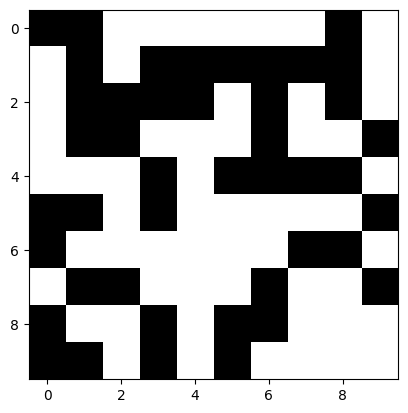

In [31]:
plt.imshow(grid,cmap=plt.cm.binary)

# Questions 4 Profilage life_step_in

 ## Question 4.a 
Avec line_profiler, profilez ligne à ligne la fonction life_step_in en ne jouant qu’une seule itération.

In [18]:
from line_profiler import profile

In [32]:
grid = init_grid((1000,1000), 0.5)
%load_ext line_profiler
%lprun -f life_step_in conway_in(grid,5)

alive cells: 500594: 50.06%
alive cells: 274920: 27.49%
alive cells: 254205: 25.42%
alive cells: 250022: 25.00%
alive cells: 238240: 23.82%


Timer unit: 1e-09 s

Total time: 62.4765 s
File: /tmp/ipykernel_15649/1224828287.py
Function: life_step_in at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           @profile
     2                                           def life_step_in(grid):
     3         5       9959.0   1991.8      0.0      irange, jrange = grid.shape
     4         5    2352257.0 470451.4      0.0      res_grid = np.zeros(grid.shape,dtype=ctype)
     5      5005    1399250.0    279.6      0.0      for j in range(jrange):
     6   5005000 1375705041.0    274.9      2.2          for i in range(irange):
     7                                                       # by default cell_state is dead
     8   5000000 1309959523.0    262.0      2.1              cell_state = False
     9                                                       # loop over neighs to count living cells
    10   5000000 2048502088.0    409.7      3.3              biinf = max(0, i

In [35]:
%lprun -f life_step conway(grid,5)

alive cells: 500594: 50.06%
alive cells: 274920: 27.49%
alive cells: 254205: 25.42%
alive cells: 250022: 25.00%
alive cells: 238240: 23.82%


Timer unit: 1e-09 s

Total time: 57.3302 s
File: /tmp/ipykernel_15649/1777359899.py
Function: life_step at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def life_step(grid):
     2         5       8738.0   1747.6      0.0      irange, jrange = grid.shape
     3         5    2889516.0 577903.2      0.0      res_grid = np.zeros(grid.shape,dtype=ctype)
     4      5005    1457964.0    291.3      0.0      for j in range(jrange):
     5   5005000 1381125691.0    275.9      2.4          for i in range(irange):
     6                                                       # by default cell_state is dead
     7   5000000 1305592411.0    261.1      2.3              cell_state = False
     8                                                       # loop over neighs to count living cells
     9   5000000     4.94e+10   9888.1     86.2              nb_neigh = get_nbneigh(grid,(i,j))
    10                                       

In [36]:
%lprun -f get_nbneigh conway(grid,5)

alive cells: 500594: 50.06%
alive cells: 274920: 27.49%
alive cells: 254205: 25.42%
alive cells: 250022: 25.00%
alive cells: 238240: 23.82%


Timer unit: 1e-09 s

Total time: 61.7163 s
File: /tmp/ipykernel_15649/3970450040.py
Function: get_nbneigh at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def get_nbneigh(grid, coord):
     2   5000000 1556274444.0    311.3      2.5      irange, jrange = grid.shape
     3   5000000 1387115520.0    277.4      2.2      i, j = coord
     4   5000000 2122449288.0    424.5      3.4      biinf = max(0, i - 1)
     5   5000000 2162973590.0    432.6      3.5      bisup = min(irange - 1, i + 1)
     6   5000000 2076078585.0    415.2      3.4      bjinf = max(0,j - 1)
     7   5000000 2102009434.0    420.4      3.4      bjsup = min(jrange - 1,j + 1)
     8   5000000 1384761699.0    277.0      2.2      nb_neigh = 0
     9                                               # loop over neighs to count living cells
    10  19990000 6069787186.0    303.6      9.8      for ii in range(biinf, bisup + 1):
    11  59930020     1.85e+10 

## Question 4.b
Quel surcoût en temps d’exécution observez-vous par rapport à une exécution sans profilage ?

In [ ]:
grid = init_grid((1000,1000), 0.5)
%time %lprun -f life_step_in conway_in(grid,5)

alive cells: 500919: 50.09%
alive cells: 273390: 27.34%
alive cells: 253654: 25.37%
alive cells: 250507: 25.05%
alive cells: 238239: 23.82%
CPU times: user 1min 30s, sys: 8 ms, total: 1min 30s
Wall time: 1min 30s


Timer unit: 1e-09 s

Total time: 64.7322 s
File: /tmp/ipykernel_15649/1224828287.py
Function: life_step_in at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           @profile
     2                                           def life_step_in(grid):
     3         5       8825.0   1765.0      0.0      irange, jrange = grid.shape
     4         5    2298765.0 459753.0      0.0      res_grid = np.zeros(grid.shape,dtype=ctype)
     5      5005    1422955.0    284.3      0.0      for j in range(jrange):
     6   5005000 1395969428.0    278.9      2.2          for i in range(irange):
     7                                                       # by default cell_state is dead
     8   5000000 1369335987.0    273.9      2.1              cell_state = False
     9                                                       # loop over neighs to count living cells
    10   5000000 2142706206.0    428.5      3.3              biinf = max(0, i

In [38]:
grid = init_grid((1000,1000), 0.5)
%time conway_in(grid,5)

alive cells: 500492: 50.05%
alive cells: 274596: 27.46%
alive cells: 254086: 25.41%
alive cells: 250771: 25.08%
alive cells: 238476: 23.85%
CPU times: user 11.4 s, sys: 2 ms, total: 11.4 s
Wall time: 11.4 s


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1000, 1000))

# Jai un surcout de presque une minute

## Question 4.c
Quels sont les hot spots mis en évidence par le profilage ligne à ligne ?

## On peut voir que l'instruction avec la condition if s'execute moins que l'instruction if et que la boucle sur jj s'execute plus que la boucle ii ce qui est tout à fait normal